<a href="https://colab.research.google.com/github/tabishqamar851/AFIFA/blob/main/Copy_of_Untitled6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance pandas matplotlib

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 3 popular Indian stocks download karenge
stocks = ['RELIANCE.NS', 'TCS.NS', 'INFY.NS']

data = yf.download(stocks, start='2023-01-01', end='2024-12-31')['Close']

print("Data downloaded successfully!")
print(data.tail())

/tmp/ipykernel_6771/3474881282.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start='2023-01-01', end='2024-12-31')['Close']
[*********************100%***********************]  3 of 3 completed

Data downloaded successfully!
Ticker          INFY.NS  RELIANCE.NS       TCS.NS
Date                                             
2024-12-23  1868.988525  1217.437744  3946.769775
2024-12-24  1854.176880  1217.885864  3966.892090
2024-12-26  1852.574341  1211.710571  3957.020996
2024-12-27  1861.655518  1216.192749  3952.987061
2024-12-30  1851.214478  1205.883789  3947.244629


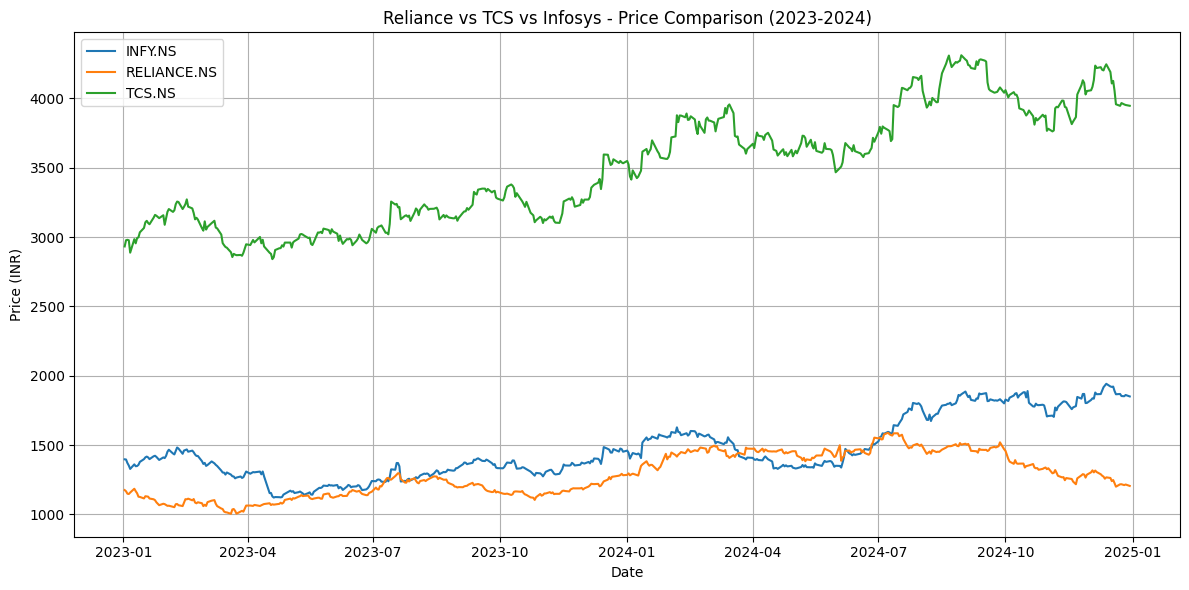

In [ ]:
# Stock price chart
plt.figure(figsize=(12, 6))

for stock in data.columns:
    plt.plot(data.index, data[stock], label=stock)

plt.title('Reliance vs TCS vs Infosys - Price Comparison (2023-2024)')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

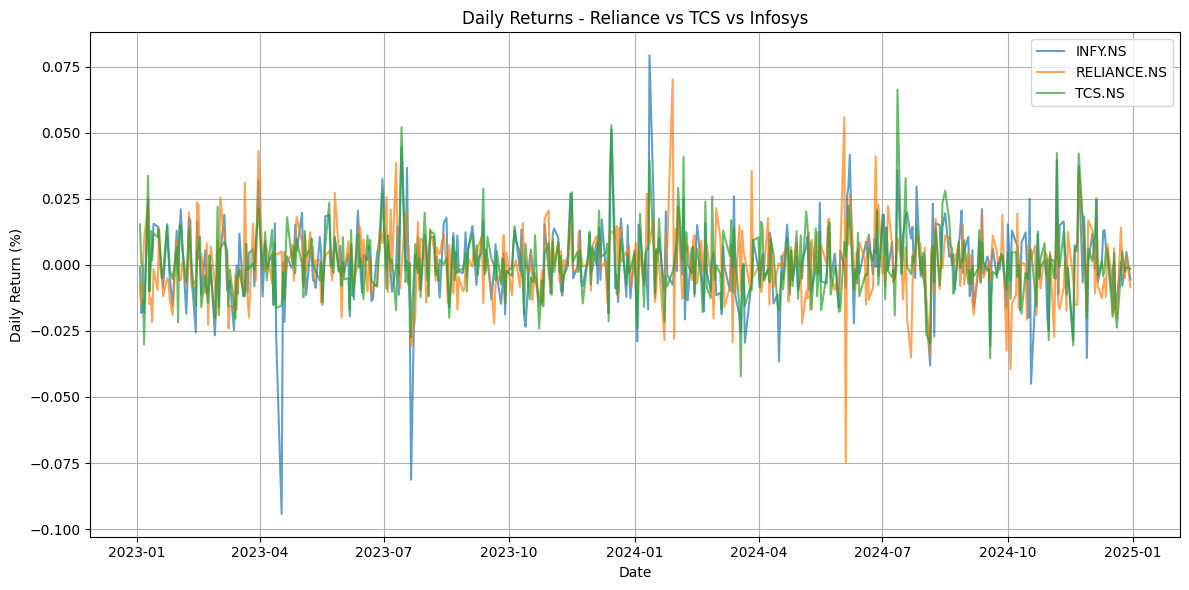


--- Return Statistics ---
Ticker   INFY.NS  RELIANCE.NS    TCS.NS
count   489.0000     489.0000  489.0000
mean      0.0007       0.0001    0.0007
std       0.0145       0.0128    0.0124
min      -0.0942      -0.0749   -0.0422
25%      -0.0071      -0.0078   -0.0059
50%      -0.0002       0.0003    0.0000
75%       0.0084       0.0073    0.0068
max       0.0793       0.0702    0.0663


In [ ]:
# Daily Returns calculate karna
returns = data.pct_change().dropna()

# Returns ka chart
plt.figure(figsize=(12, 6))

for stock in returns.columns:
    plt.plot(returns.index, returns[stock], label=stock, alpha=0.7)

plt.title('Daily Returns - Reliance vs TCS vs Infosys')
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Summary statistics
print("\n--- Return Statistics ---")
print(returns.describe().round(4))

--- Risk vs Return Summary ---
INFY.NS: Return=17.16%, Risk=23.09%
RELIANCE.NS: Return=3.36%, Risk=20.36%
TCS.NS: Return=17.24%, Risk=19.70%


/tmp/ipykernel_6771/102158689.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(stock, (risk[i], avg_return[i]),


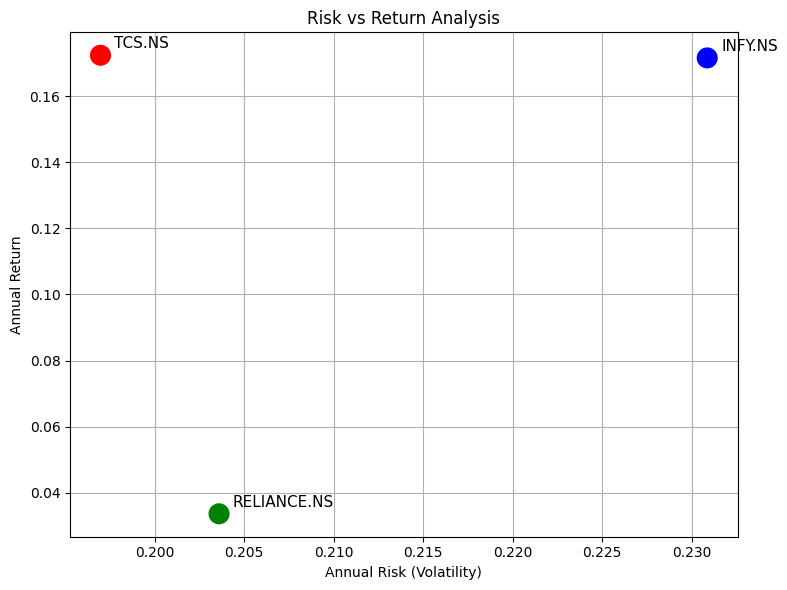

In [ ]:
# Risk vs Return Analysis
avg_return = returns.mean() * 252  # Annual return
risk = returns.std() * (252**0.5)  # Annual volatility

print("--- Risk vs Return Summary ---")
for stock in data.columns:
    print(f"{stock}: Return={avg_return[stock]:.2%}, Risk={risk[stock]:.2%}")

# Risk vs Return scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(risk, avg_return, s=200, color=['blue', 'green', 'red'])

for i, stock in enumerate(data.columns):
    plt.annotate(stock, (risk[i], avg_return[i]),
                textcoords="offset points", xytext=(10,5), fontsize=11)

plt.title('Risk vs Return Analysis')
plt.xlabel('Annual Risk (Volatility)')
plt.ylabel('Annual Return')
plt.grid(True)
plt.tight_layout()
plt.show()

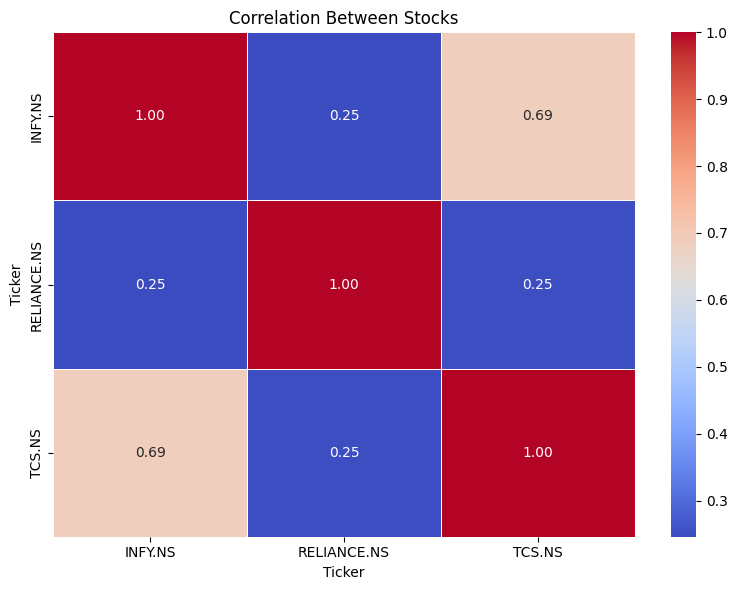


--- Correlation Matrix ---
Ticker       INFY.NS  RELIANCE.NS  TCS.NS
Ticker                                   
INFY.NS         1.00         0.25    0.69
RELIANCE.NS     0.25         1.00    0.25
TCS.NS          0.69         0.25    1.00


In [ ]:
# Correlation Heatmap - stocks kitne related hain
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(returns.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)

plt.title('Correlation Between Stocks')
plt.tight_layout()
plt.show()

print("\n--- Correlation Matrix ---")
print(returns.corr().round(2))

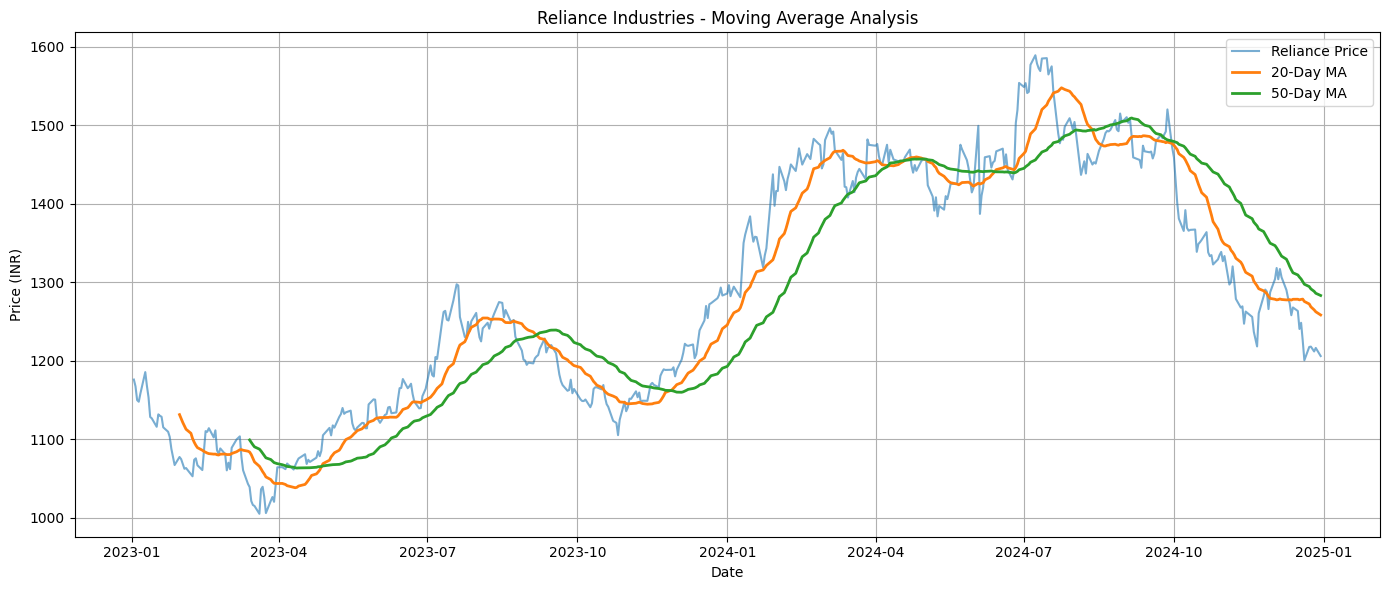

In [ ]:
# Moving Averages - trend analysis
plt.figure(figsize=(14, 6))

# Sirf Reliance ke liye dikhate hain
reliance = data['RELIANCE.NS']

ma_20 = reliance.rolling(window=20).mean()
ma_50 = reliance.rolling(window=50).mean()

plt.plot(reliance.index, reliance, label='Reliance Price', alpha=0.6)
plt.plot(reliance.index, ma_20, label='20-Day MA', linewidth=2)
plt.plot(reliance.index, ma_50, label='50-Day MA', linewidth=2)

plt.title('Reliance Industries - Moving Average Analysis')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6771/2789932737.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[1,0].annotate(stock, (risk[i], avg_return[i]), xytext=(5,5), textcoords="offset points", fontsize=9)


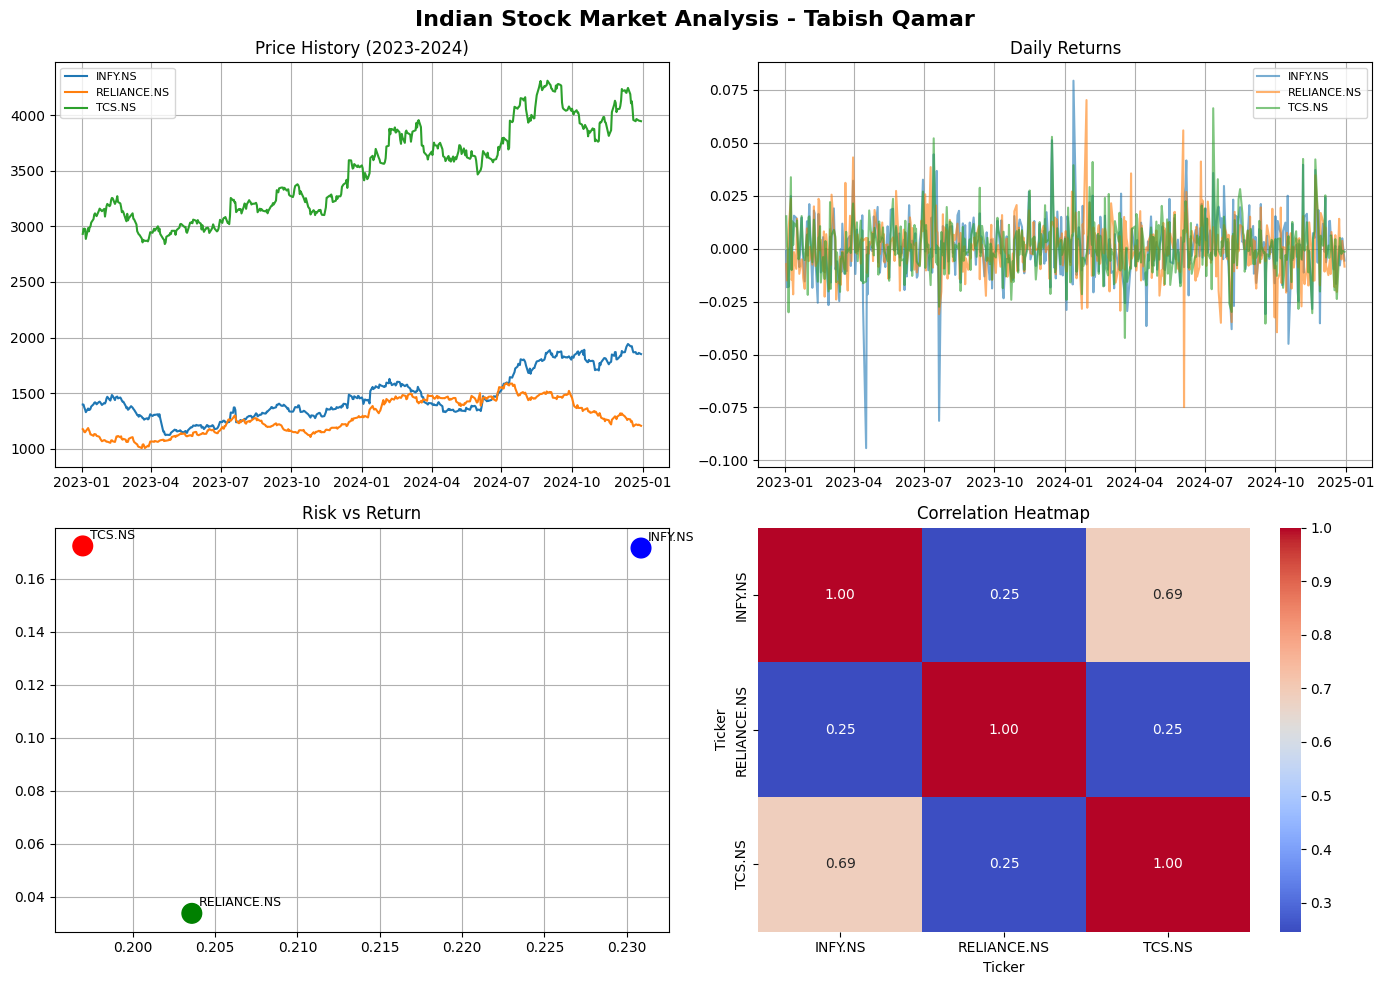

✅ Project Complete! Chart saved as stock_analysis.png


In [ ]:
# Final Summary - Ek saath sab dikhao
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Indian Stock Market Analysis - Tabish Qamar', fontsize=16, fontweight='bold')

# 1. Price History
for stock in data.columns:
    axes[0,0].plot(data.index, data[stock], label=stock)
axes[0,0].set_title('Price History (2023-2024)')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(True)

# 2. Daily Returns
for stock in returns.columns:
    axes[0,1].plot(returns.index, returns[stock], label=stock, alpha=0.6)
axes[0,1].set_title('Daily Returns')
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True)

# 3. Risk vs Return
axes[1,0].scatter(risk, avg_return, s=200, color=['blue','green','red'])
for i, stock in enumerate(data.columns):
    axes[1,0].annotate(stock, (risk[i], avg_return[i]), xytext=(5,5), textcoords="offset points", fontsize=9)
axes[1,0].set_title('Risk vs Return')
axes[1,0].grid(True)

# 4. Correlation Heatmap
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm', ax=axes[1,1], fmt='.2f')
axes[1,1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('stock_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Project Complete! Chart saved as stock_analysis.png")